In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables
import pandas as pd

In [2]:
df = pd.read_hdf('../../dataset_complete/BDT/BDT_all.h5', key='data')

fCC = tables.open_file('../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../dataset_complete/merger/merged_NC_0.h5', mode='r')

In [3]:
df.keys()

Index(['Label', 'EventCounter', 'RecoEnergy', 'CogDistance', 'TotalmDOMCharge',
       'TotalCharge', 'Beta1Reco', 'Beta2Reco', 'Beta3Reco', 'Beta4Reco',
       'Beta5Reco', 'tres_mean', 'tres_std', 'tres_median', 'tres_iqr',
       'tres_sum', 'tres_kurtosis', 'tres_skew', 'dist_mean', 'dist_std',
       'dist_median', 'dist_iqr', 'dist_sum', 'dist_kurtosis', 'dist_skew',
       'ang_mean', 'ang_std', 'ang_median', 'ang_iqr', 'ang_sum',
       'ang_kurtosis', 'ang_skew'],
      dtype='object')

In [4]:
boolCC = (df.Label == 1)
boolNC = (df.Label == 0)

Closing remaining open files:../../dataset_complete/merger/merged_NC_0.h5...done../../dataset_complete/merger/merged_CC_0.h5...done


In [5]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):

    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 10
    else:
        max_val = 30 #charge
    
    for i in range(0, max_val):#range(0, len(charge_val)-1):#
        qmin= i*10 #charge_val[i]#
        qmax= (i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])

            #plt.hist(xCC[maskCC], bins=100, histtype='step', log=True, density=True, label='CC', lw=2)
            #plt.hist(xNC[maskNC], bins=100, histtype='step', log=True, density=True, label='NC', lw=2)
            #plt.title(np.round(ks_statistic, 3))
            #plt.show()
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-0.5) #append(qmax - 5)

    return sep_var, p_val, bin_centers

In [7]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 2 #np.log10(100)
    else:
        max_val = 2.5 #np.log10(100) #charge

    steps = np.arange(0, max_val, 0.1)

    #print(steps)

    diff_varCC = np.log10(diff_varCC)
    diff_varNC = np.log10(diff_varNC)
        
    for i in steps:#range(0, len(charge_val)-1):#
        
        qmin= i #charge_val[i]#
        qmax= i+0.1 #charge_val[i+1]#

        #print(qmin, qmax)
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len(xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-(0.1/2)) #append(qmax - 5)

            #plt.hist(xCC[maskCC], bins=100, histtype='step', log=True, density=True, label='CC', lw=2)
            #plt.hist(xNC[maskNC], bins=100, histtype='step', log=True, density=True, label='NC', lw=2)
            #plt.title(np.round(ks_statistic, 3))
            #plt.show()

    return sep_var, p_val, bin_centers

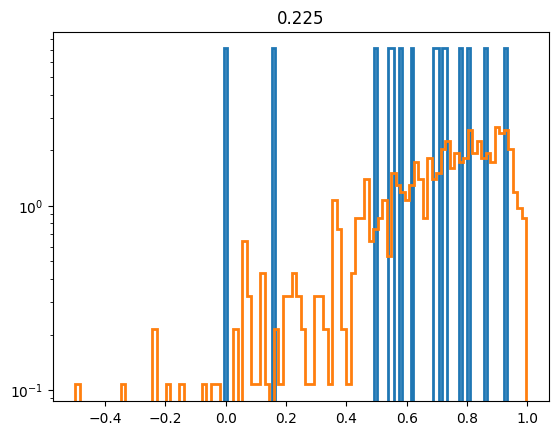

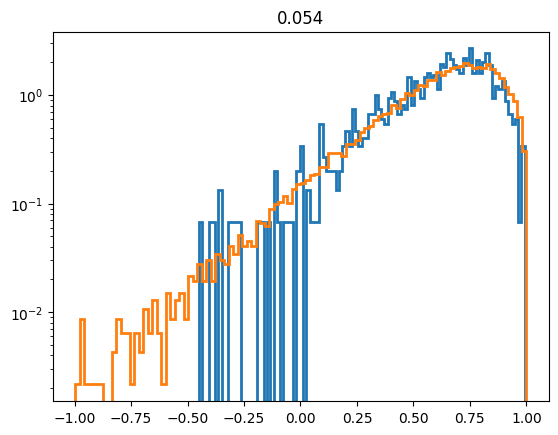

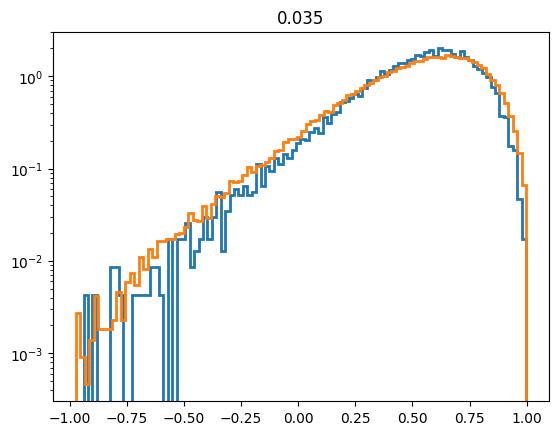

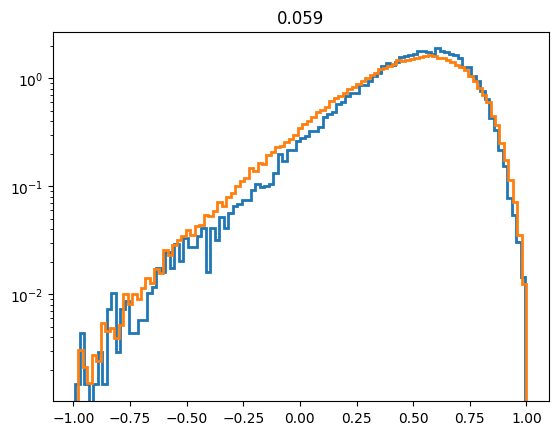

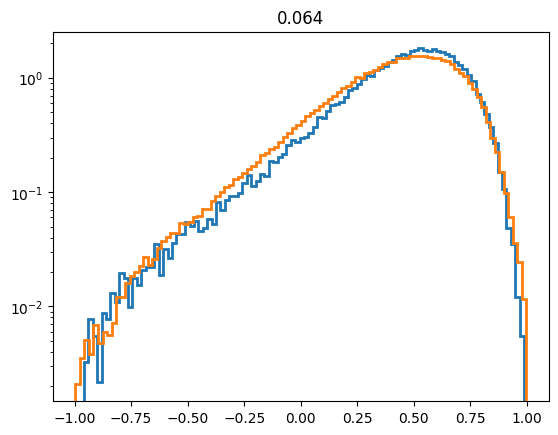

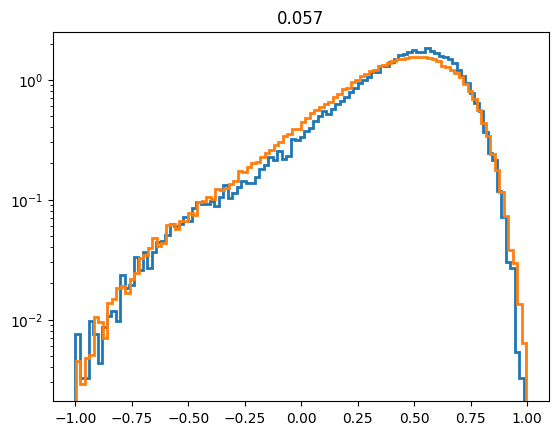

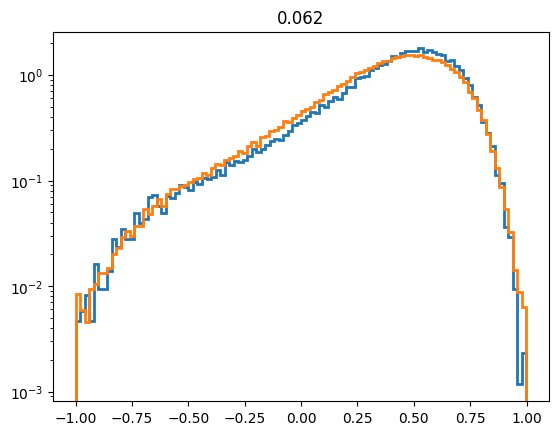

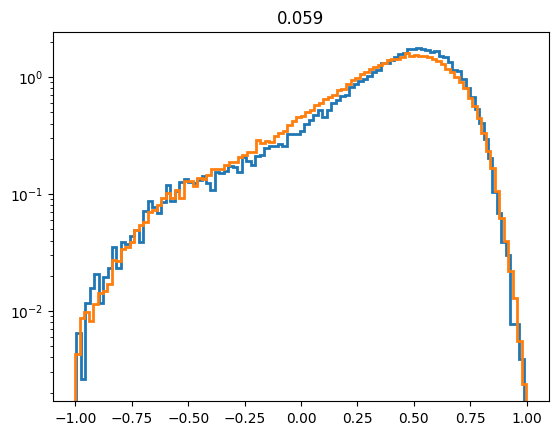

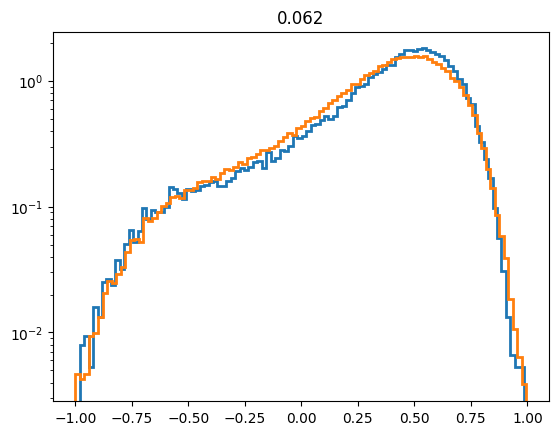

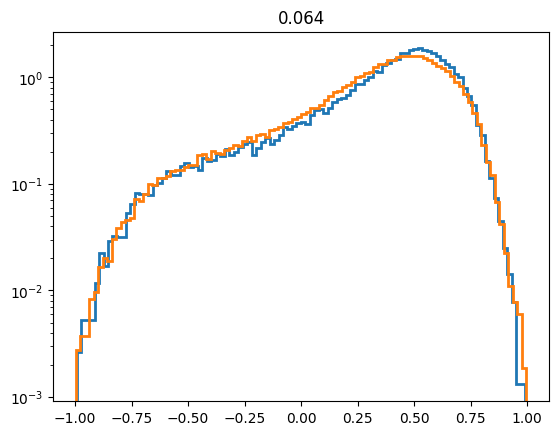

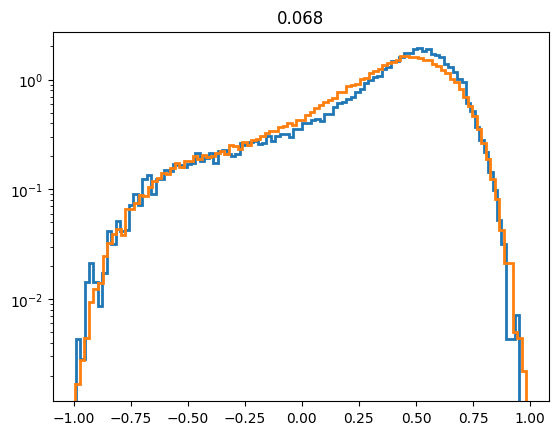

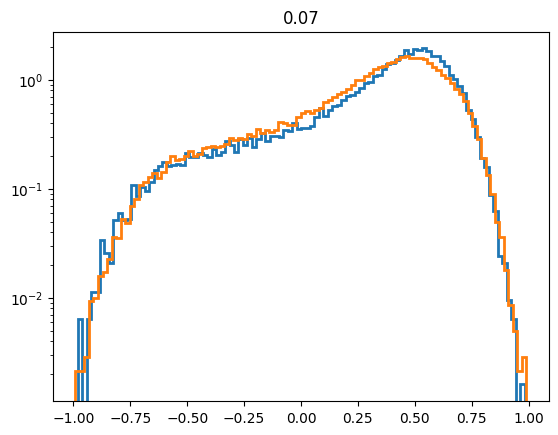

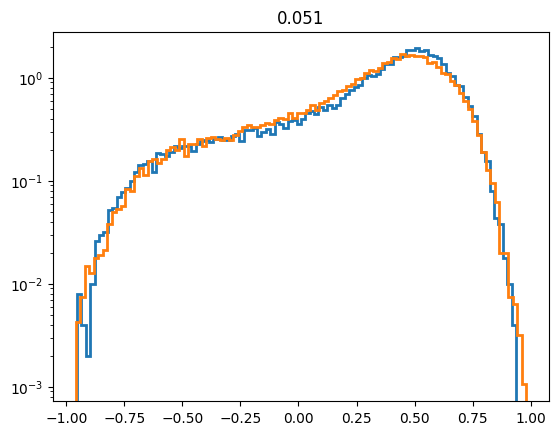

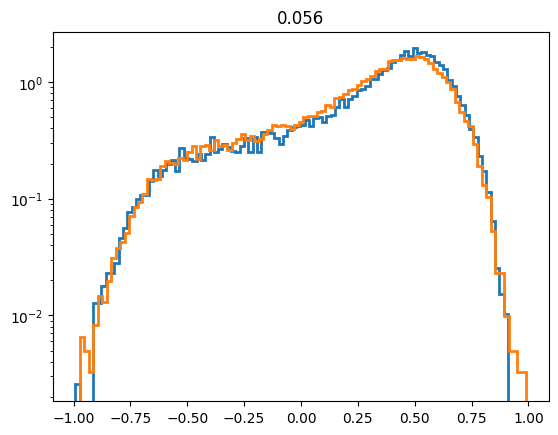

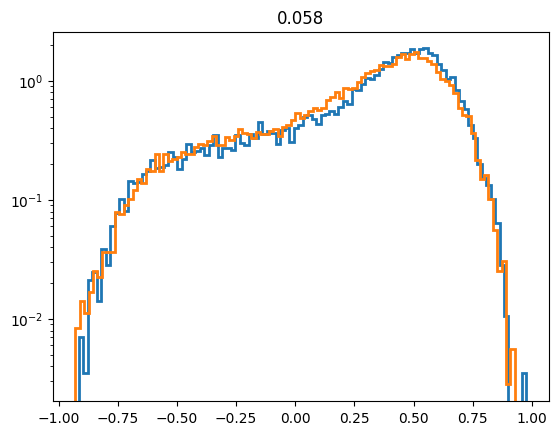

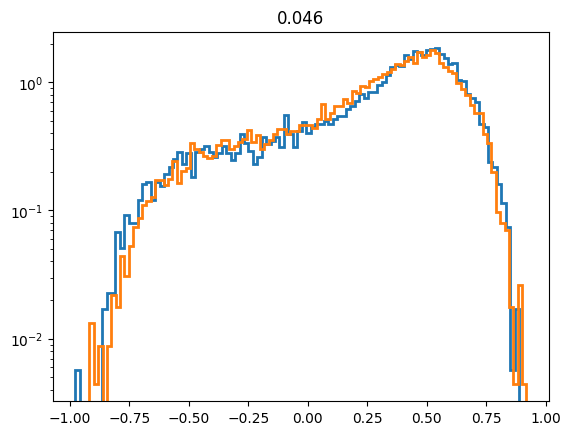

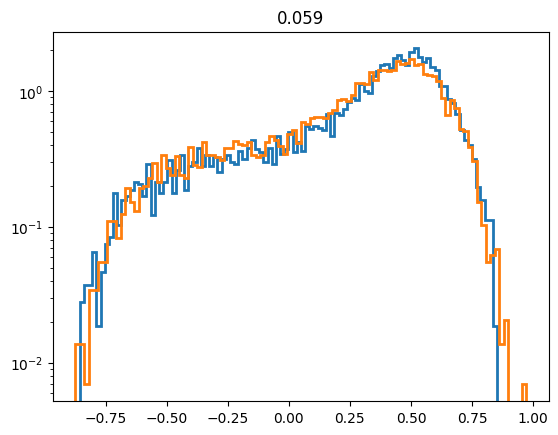

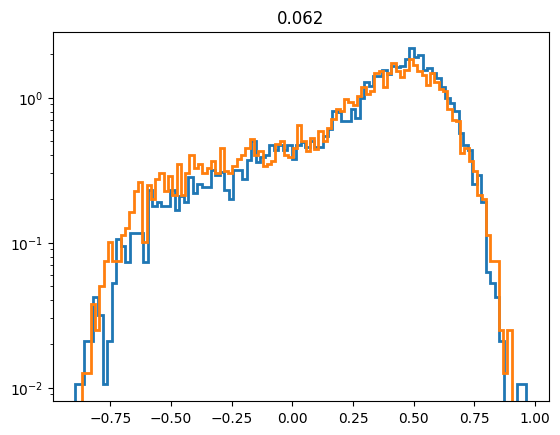

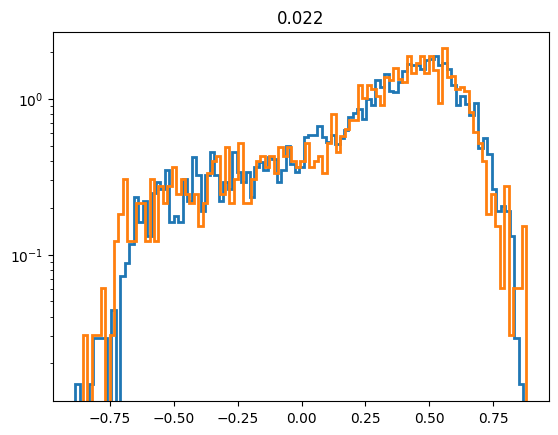

In [9]:
sep_var_mean, p_val_mean, bin_centers_mean = get_statistic(df.ang_mean[boolCC], df.ang_mean[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

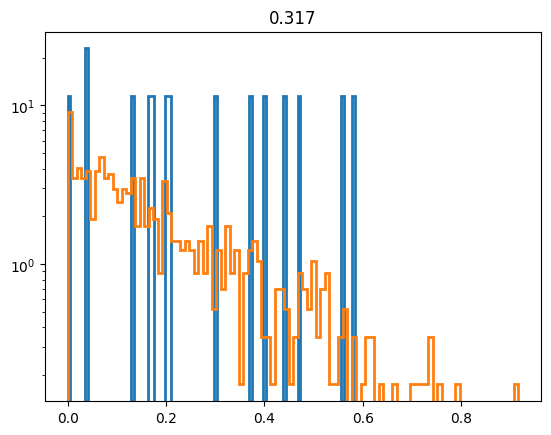

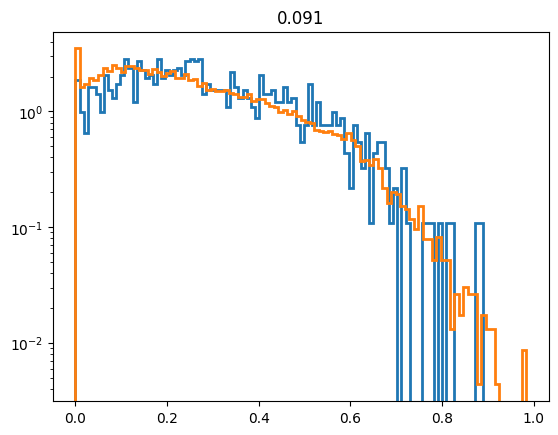

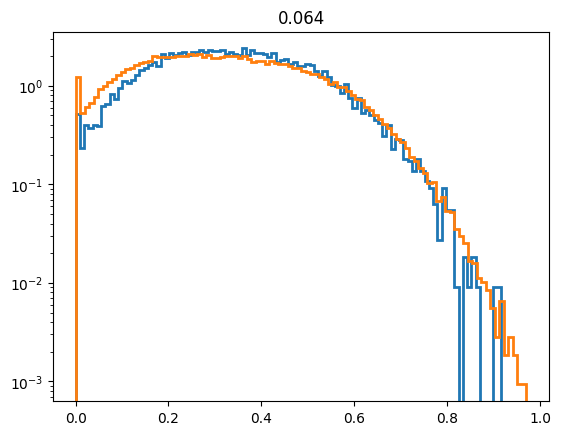

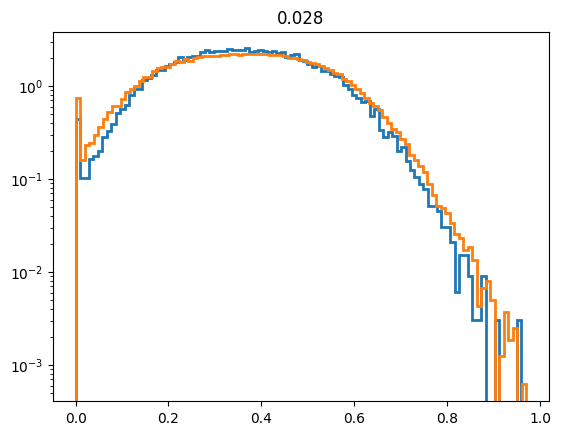

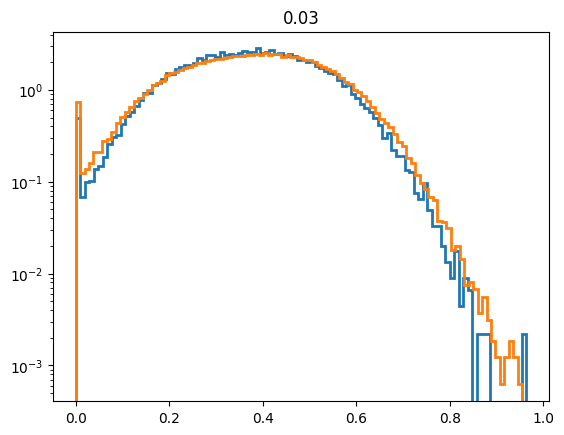

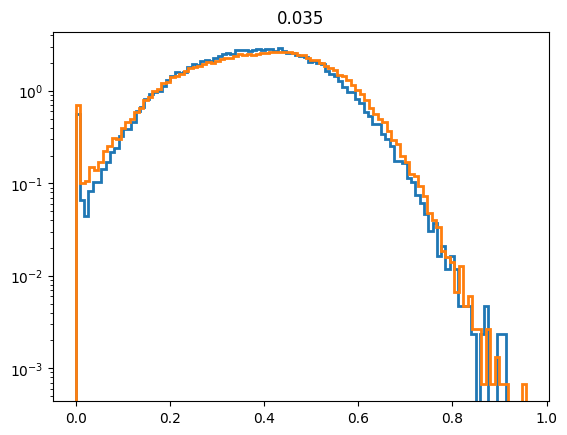

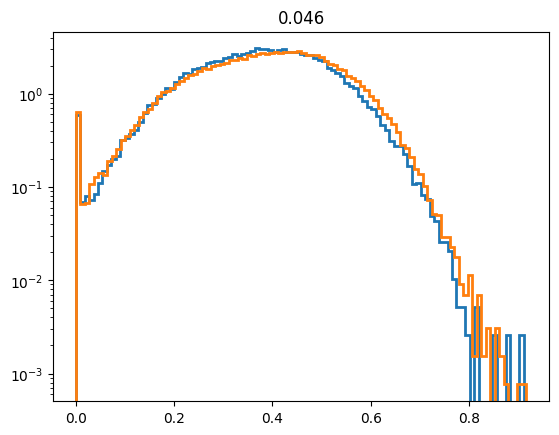

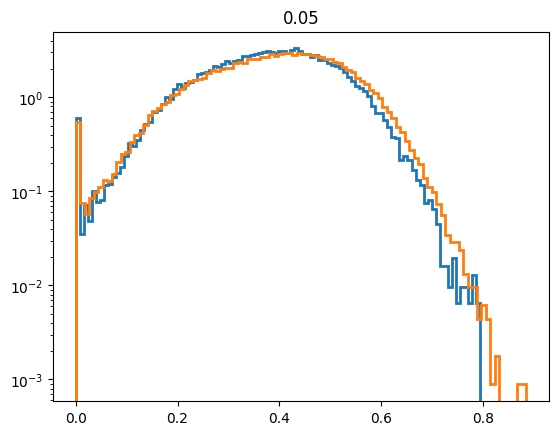

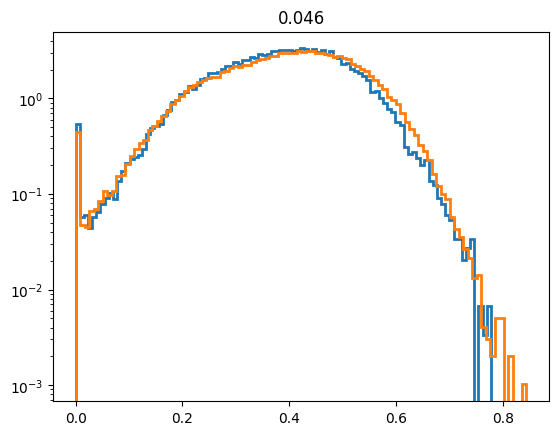

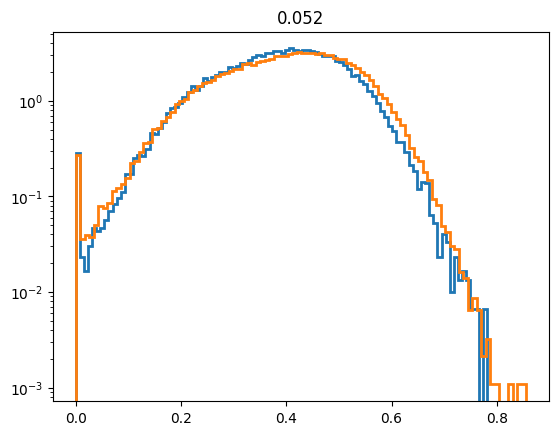

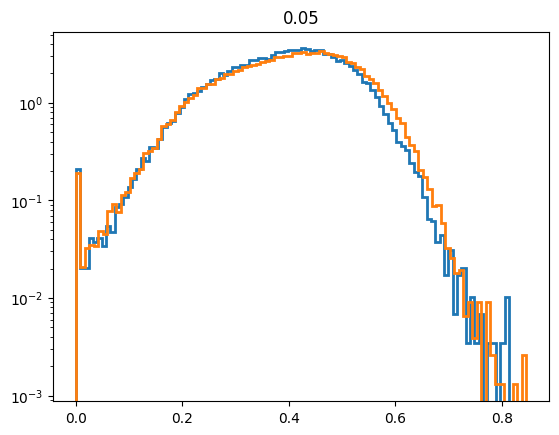

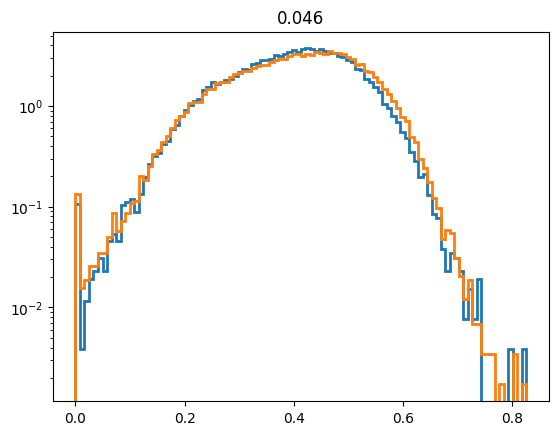

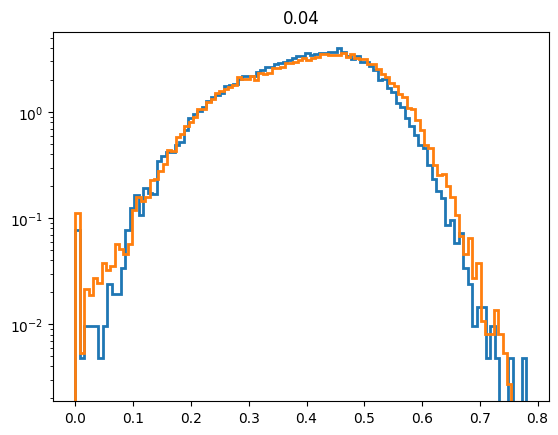

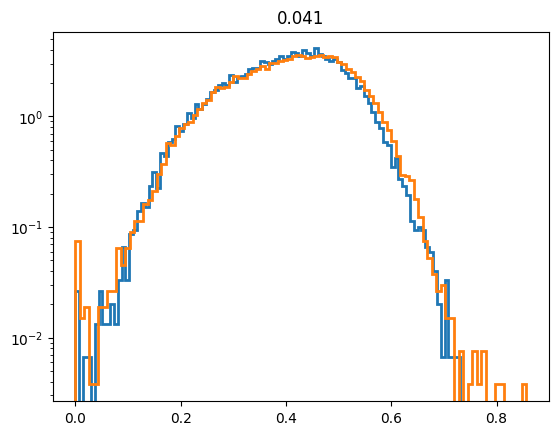

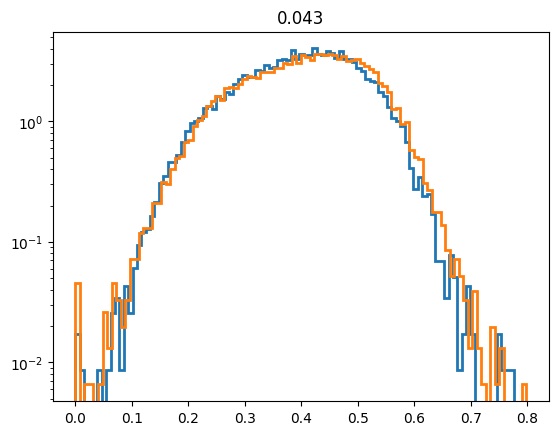

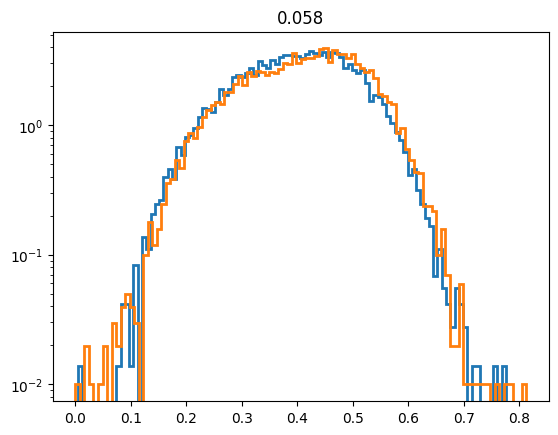

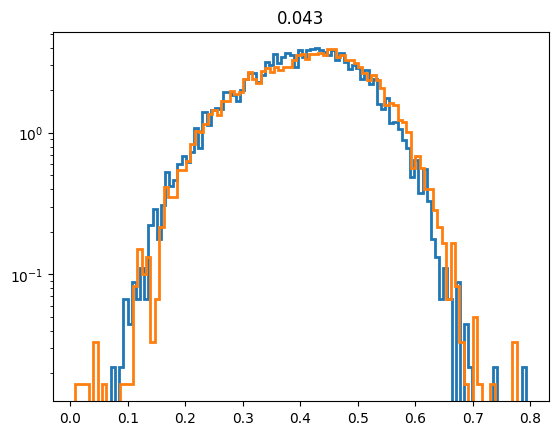

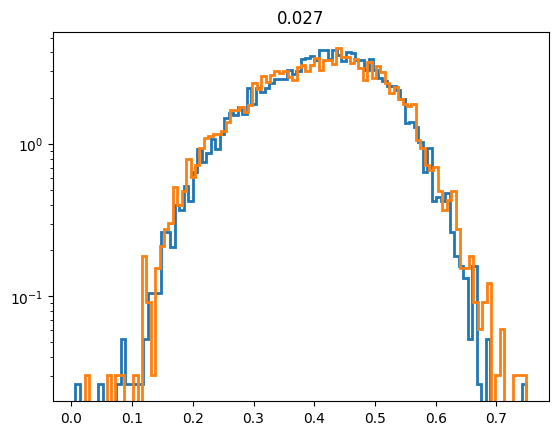

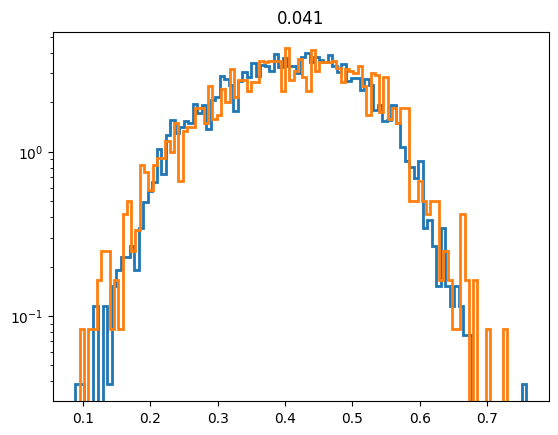

In [10]:
sep_var_std, p_val_std, bin_centers_std = get_statistic(df.ang_std[boolCC], df.ang_std[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

In [9]:
sep_var_mean, p_val_mean, bin_centers_mean = get_statistic(df.ang_mean[boolCC], df.ang_mean[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_std, p_val_std, bin_centers_std = get_statistic(df.ang_std[boolCC], df.ang_std[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_median, p_val_median, bin_centers_median = get_statistic(df.ang_median[boolCC], df.ang_median[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_iqr, p_val_iqr, bin_centers_iqr = get_statistic(df.ang_iqr[boolCC], df.ang_iqr[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_sum, p_val_sum, bin_centers_sum = get_statistic(df.ang_sum[boolCC], df.ang_sum[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_kurtosis, p_val_kurtosis, bin_centers_kurtosis = get_statistic(df.ang_kurtosis[boolCC], df.ang_kurtosis[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_skew, p_val_skew, bin_centers_skew = get_statistic(df.ang_skew[boolCC], df.ang_skew[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

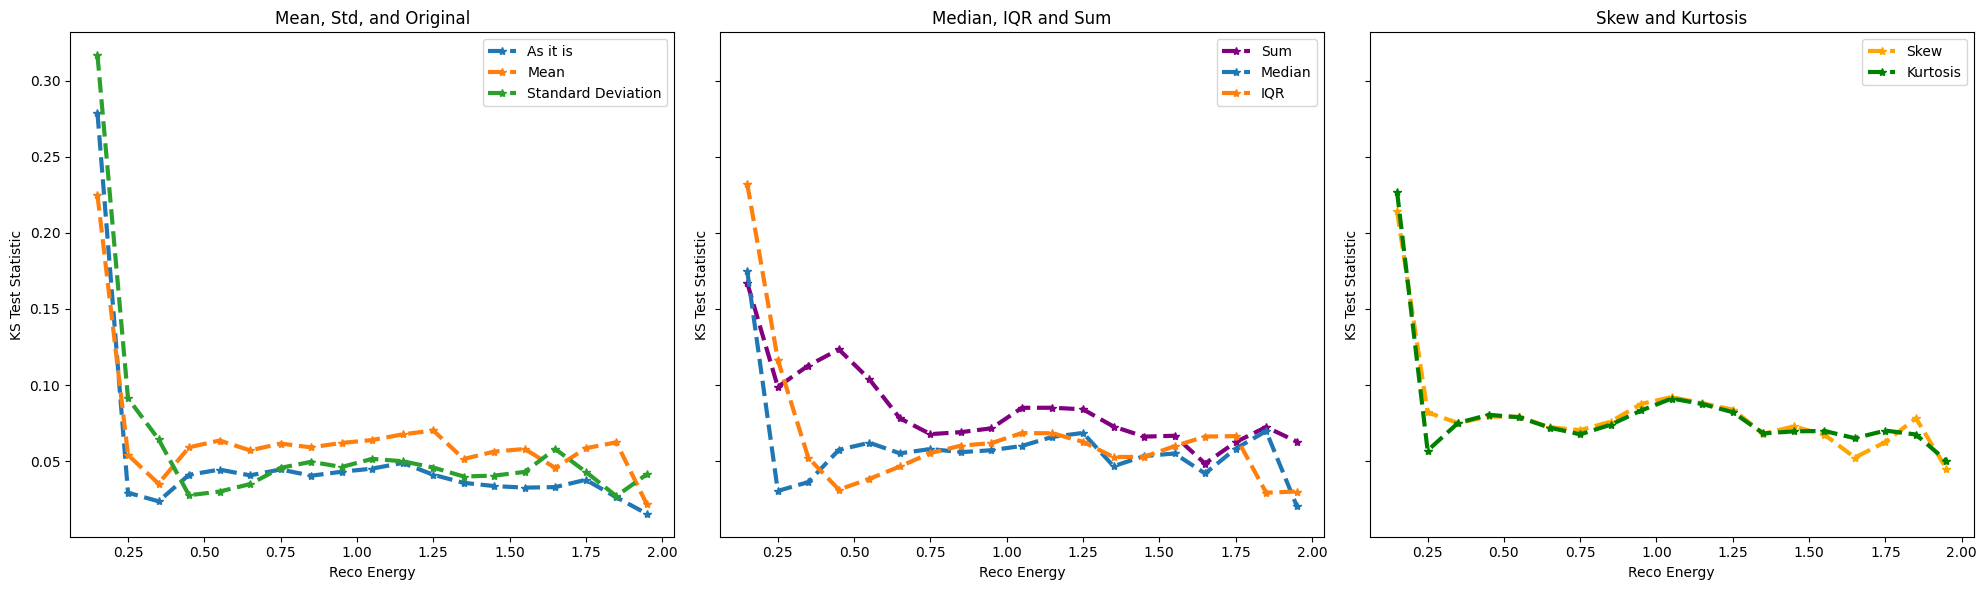

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- Subplot 1 ---
axs[0].plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='As it is')
axs[0].plot(bin_centers_mean, sep_var_mean, '*--', linewidth=3, label='Mean')
axs[0].plot(bin_centers_std, sep_var_std, '*--', linewidth=3, label='Standard Deviation')
axs[0].set_ylabel('KS Test Statistic')
axs[0].set_xlabel('Reco Energy')
axs[0].legend()
axs[0].set_title("Mean, Std, and Original")

# --- Subplot 2 ---
axs[1].plot(bin_centers_sum, sep_var_sum, '*--', linewidth=3, label='Sum', color='purple')
axs[1].plot(bin_centers_median, sep_var_median, '*--', linewidth=3, label='Median')
axs[1].plot(bin_centers_iqr, sep_var_iqr, '*--', linewidth=3, label='IQR')
axs[1].set_ylabel('KS Test Statistic')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].set_title("Median, IQR and Sum")

# --- Subplot 3 ---
axs[2].plot(bin_centers_skew, sep_var_skew, '*--', linewidth=3, label='Skew', color='orange')
axs[2].plot(bin_centers_kurtosis, sep_var_kurtosis, '*--', linewidth=3, label='Kurtosis', color='green')
axs[2].set_xlabel('Reco Energy')
axs[2].set_ylabel('KS Test Statistic')
axs[2].legend()
axs[2].set_title("Skew and Kurtosis")

plt.tight_layout()
plt.show()

In [11]:
csep_var_mean, cp_val_mean, cbin_centers_mean = get_statistic(df.ang_mean[boolCC], df.ang_mean[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_std, cp_val_std, cbin_centers_std = get_statistic(df.ang_std[boolCC], df.ang_std[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_median, cp_val_median, cbin_centers_median = get_statistic(df.ang_median[boolCC], df.ang_median[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_iqr, cp_val_iqr, cbin_centers_iqr = get_statistic(df.ang_iqr[boolCC], df.ang_iqr[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_sum, cp_val_sum, cbin_centers_sum = get_statistic(df.ang_sum[boolCC], df.ang_sum[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_kurtosis, cp_val_kurtosis, cbin_centers_kurtosis = get_statistic(df.ang_kurtosis[boolCC], df.ang_kurtosis[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_skew, cp_val_skew, cbin_centers_skew = get_statistic(df.ang_skew[boolCC], df.ang_skew[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)

csep_var_angle_reco, cp_val_angle_reco, cbin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

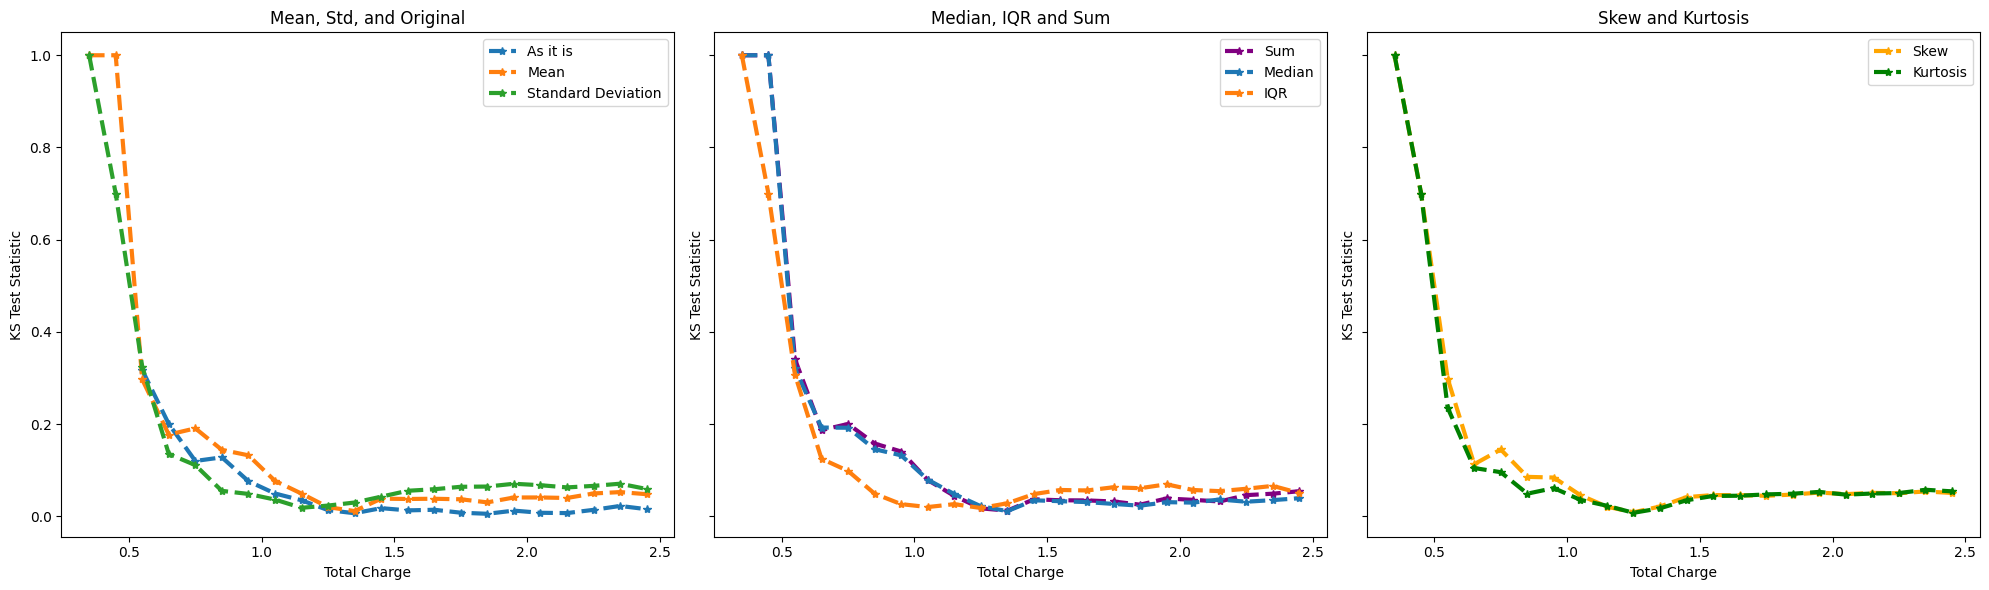

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- Subplot 1 ---
axs[0].plot(cbin_centers_angle_reco, csep_var_angle_reco, '*--', linewidth=3, label='As it is')
axs[0].plot(cbin_centers_mean, csep_var_mean, '*--', linewidth=3, label='Mean')
axs[0].plot(cbin_centers_std, csep_var_std, '*--', linewidth=3, label='Standard Deviation')
axs[0].set_ylabel('KS Test Statistic')
axs[0].set_xlabel('Total Charge')
axs[0].legend()
axs[0].set_title("Mean, Std, and Original")

# --- Subplot 2 ---
axs[1].plot(cbin_centers_sum, csep_var_sum, '*--', linewidth=3, label='Sum', color='purple')
axs[1].plot(cbin_centers_median, csep_var_median, '*--', linewidth=3, label='Median')
axs[1].plot(cbin_centers_iqr, csep_var_iqr, '*--', linewidth=3, label='IQR')
axs[1].set_ylabel('KS Test Statistic')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].set_title("Median, IQR and Sum")

# --- Subplot 3 ---
axs[2].plot(cbin_centers_skew, csep_var_skew, '*--', linewidth=3, label='Skew', color='orange')
axs[2].plot(cbin_centers_kurtosis, csep_var_kurtosis, '*--', linewidth=3, label='Kurtosis', color='green')
axs[2].set_xlabel('Total Charge')
axs[2].set_ylabel('KS Test Statistic')
axs[2].legend()
axs[2].set_title("Skew and Kurtosis")

plt.tight_layout()
plt.show()

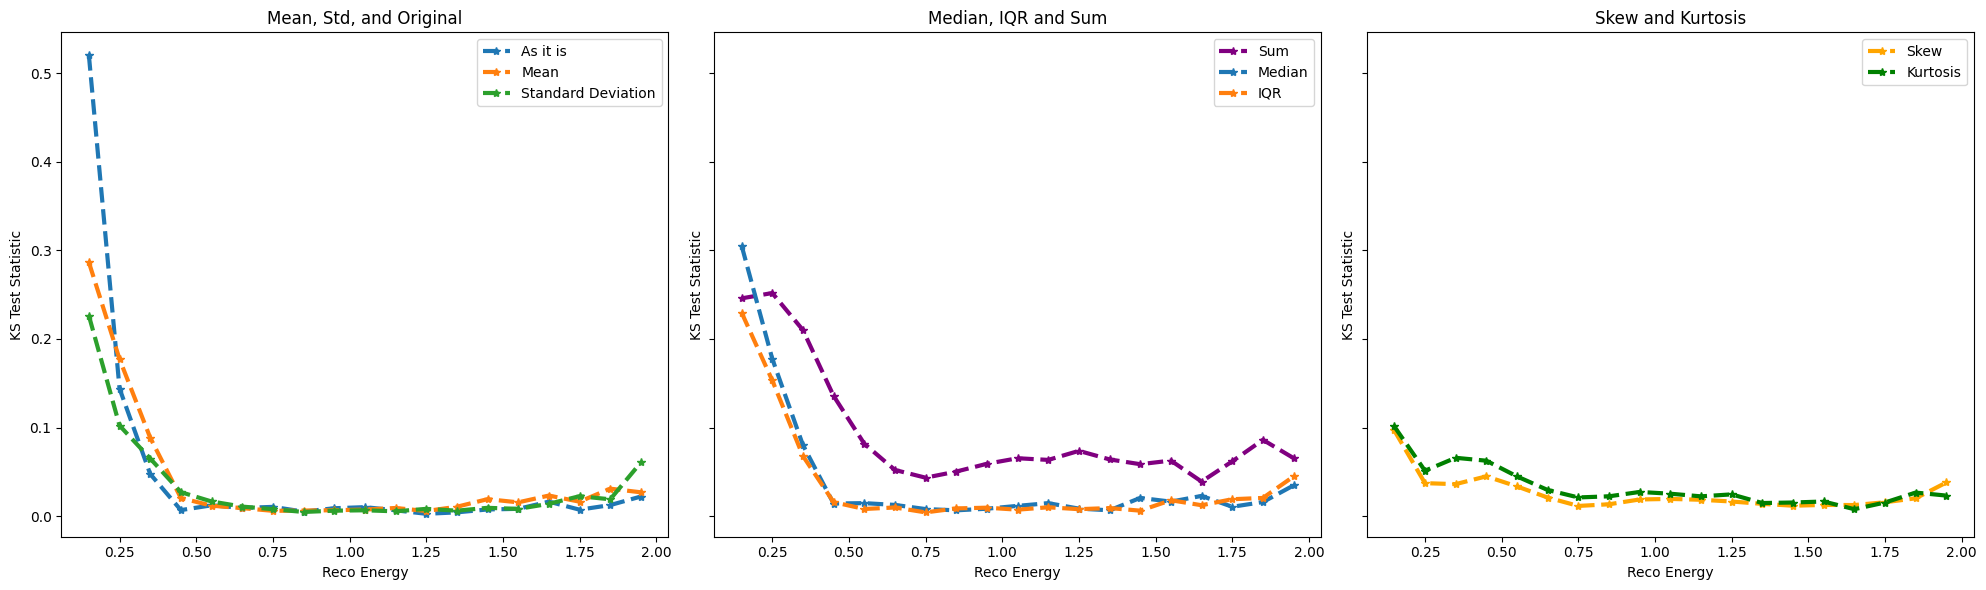

In [13]:
sep_var_mean, p_val_mean, bin_centers_mean = get_statistic(df.dist_mean[boolCC], df.dist_mean[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_std, p_val_std, bin_centers_std = get_statistic(df.dist_std[boolCC], df.dist_std[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_median, p_val_median, bin_centers_median = get_statistic(df.dist_median[boolCC], df.dist_median[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_iqr, p_val_iqr, bin_centers_iqr = get_statistic(df.dist_iqr[boolCC], df.dist_iqr[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_sum, p_val_sum, bin_centers_sum = get_statistic(df.dist_sum[boolCC], df.dist_sum[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_kurtosis, p_val_kurtosis, bin_centers_kurtosis = get_statistic(df.dist_kurtosis[boolCC], df.dist_kurtosis[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_skew, p_val_skew, bin_centers_skew = get_statistic(df.dist_skew[boolCC], df.dist_skew[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(fCC.root.OMMapReco.col('distance'), fNC.root.OMMapReco.col('distance'), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- Subplot 1 ---
axs[0].plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='As it is')
axs[0].plot(bin_centers_mean, sep_var_mean, '*--', linewidth=3, label='Mean')
axs[0].plot(bin_centers_std, sep_var_std, '*--', linewidth=3, label='Standard Deviation')
axs[0].set_ylabel('KS Test Statistic')
axs[0].set_xlabel('Reco Energy')
axs[0].legend()
axs[0].set_title("Mean, Std, and Original")

# --- Subplot 2 ---
axs[1].plot(bin_centers_sum, sep_var_sum, '*--', linewidth=3, label='Sum', color='purple')
axs[1].plot(bin_centers_median, sep_var_median, '*--', linewidth=3, label='Median')
axs[1].plot(bin_centers_iqr, sep_var_iqr, '*--', linewidth=3, label='IQR')
axs[1].set_ylabel('KS Test Statistic')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].set_title("Median, IQR and Sum")

# --- Subplot 3 ---
axs[2].plot(bin_centers_skew, sep_var_skew, '*--', linewidth=3, label='Skew', color='orange')
axs[2].plot(bin_centers_kurtosis, sep_var_kurtosis, '*--', linewidth=3, label='Kurtosis', color='green')
axs[2].set_xlabel('Reco Energy')
axs[2].set_ylabel('KS Test Statistic')
axs[2].legend()
axs[2].set_title("Skew and Kurtosis")

plt.tight_layout()
plt.show()

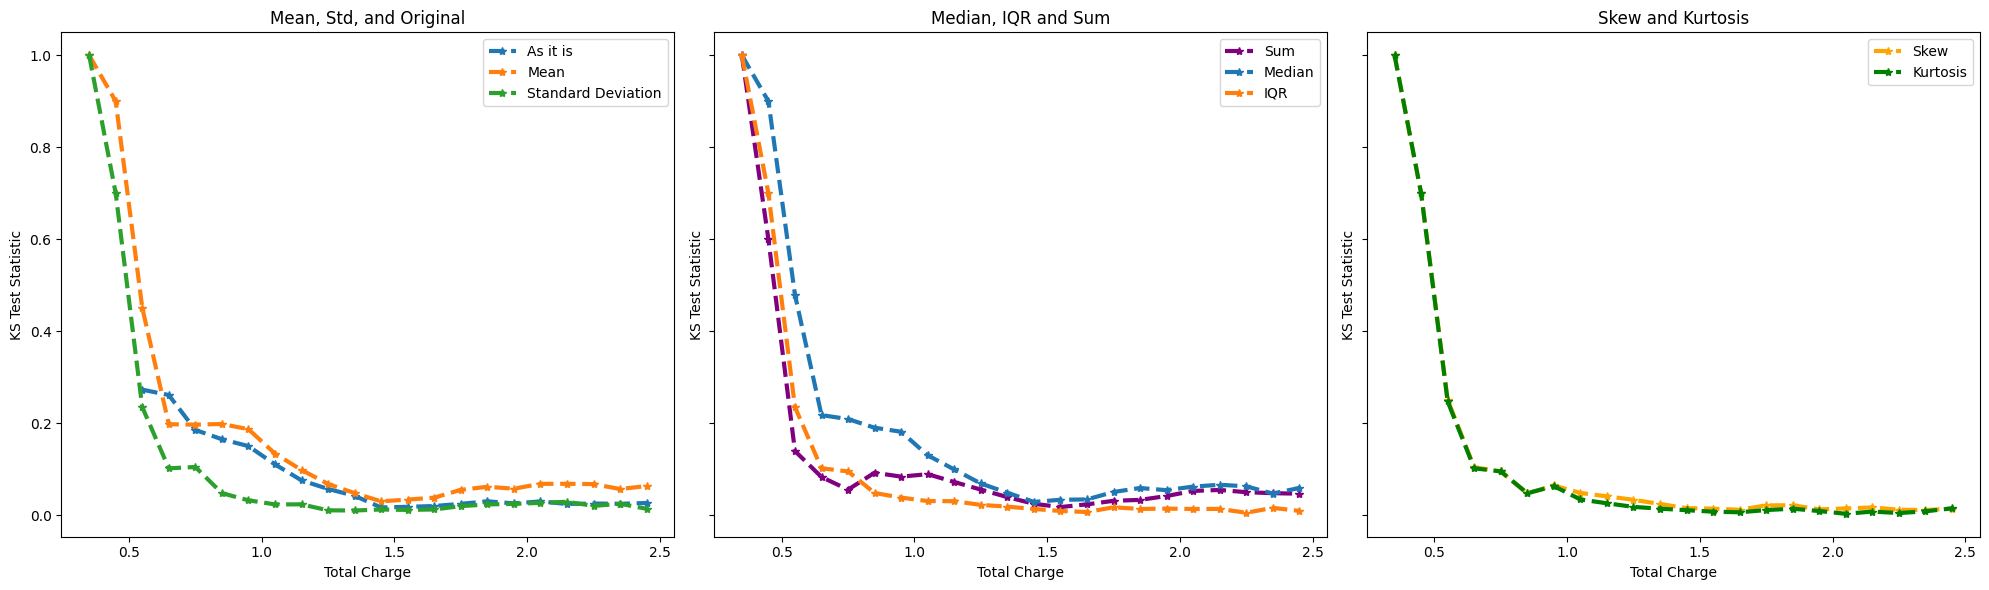

In [14]:
csep_var_mean, cp_val_mean, cbin_centers_mean = get_statistic(df.dist_mean[boolCC], df.dist_mean[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_std, cp_val_std, cbin_centers_std = get_statistic(df.dist_std[boolCC], df.dist_std[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_median, cp_val_median, cbin_centers_median = get_statistic(df.dist_median[boolCC], df.dist_median[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_iqr, cp_val_iqr, cbin_centers_iqr = get_statistic(df.dist_iqr[boolCC], df.dist_iqr[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_sum, cp_val_sum, cbin_centers_sum = get_statistic(df.dist_sum[boolCC], df.dist_sum[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_kurtosis, cp_val_kurtosis, cbin_centers_kurtosis = get_statistic(df.dist_kurtosis[boolCC], df.dist_kurtosis[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_skew, cp_val_skew, cbin_centers_skew = get_statistic(df.dist_skew[boolCC], df.dist_skew[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)

csep_var_angle_reco, cp_val_angle_reco, cbin_centers_angle_reco = get_statistic(fCC.root.OMMapReco.col('distance'), fNC.root.OMMapReco.col('distance'), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- Subplot 1 ---
axs[0].plot(cbin_centers_angle_reco, csep_var_angle_reco, '*--', linewidth=3, label='As it is')
axs[0].plot(cbin_centers_mean, csep_var_mean, '*--', linewidth=3, label='Mean')
axs[0].plot(cbin_centers_std, csep_var_std, '*--', linewidth=3, label='Standard Deviation')
axs[0].set_ylabel('KS Test Statistic')
axs[0].set_xlabel('Total Charge')
axs[0].legend()
axs[0].set_title("Mean, Std, and Original")

# --- Subplot 2 ---
axs[1].plot(cbin_centers_sum, csep_var_sum, '*--', linewidth=3, label='Sum', color='purple')
axs[1].plot(cbin_centers_median, csep_var_median, '*--', linewidth=3, label='Median')
axs[1].plot(cbin_centers_iqr, csep_var_iqr, '*--', linewidth=3, label='IQR')
axs[1].set_ylabel('KS Test Statistic')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].set_title("Median, IQR and Sum")

# --- Subplot 3 ---
axs[2].plot(cbin_centers_skew, csep_var_skew, '*--', linewidth=3, label='Skew', color='orange')
axs[2].plot(cbin_centers_kurtosis, csep_var_kurtosis, '*--', linewidth=3, label='Kurtosis', color='green')
axs[2].set_xlabel('Total Charge')
axs[2].set_ylabel('KS Test Statistic')
axs[2].legend()
axs[2].set_title("Skew and Kurtosis")

plt.tight_layout()
plt.show()

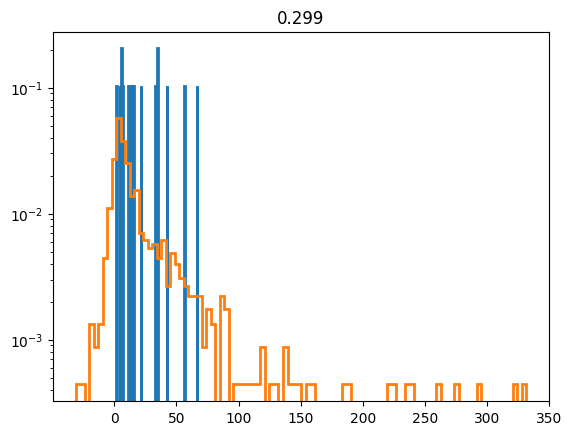

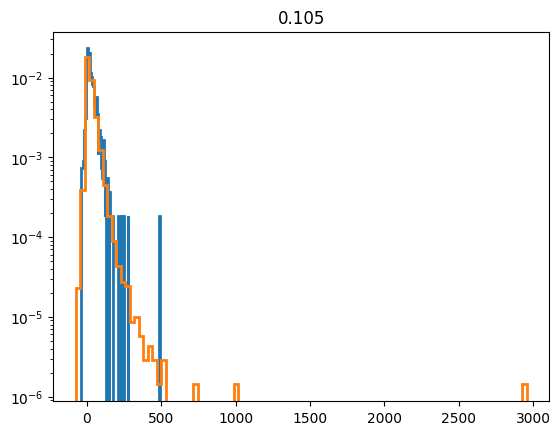

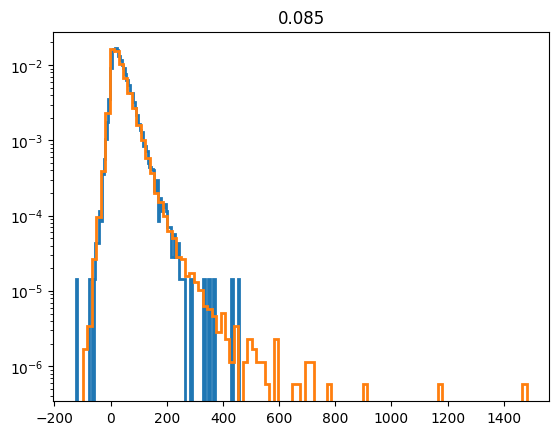

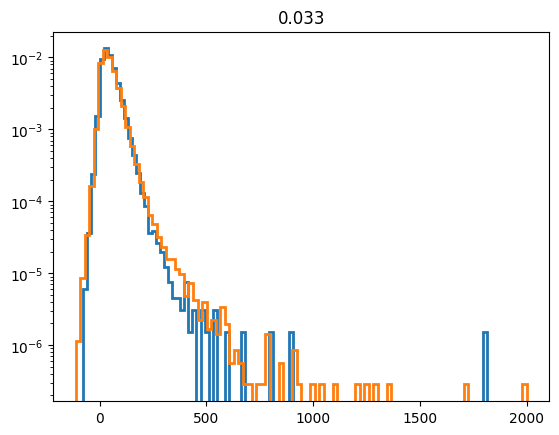

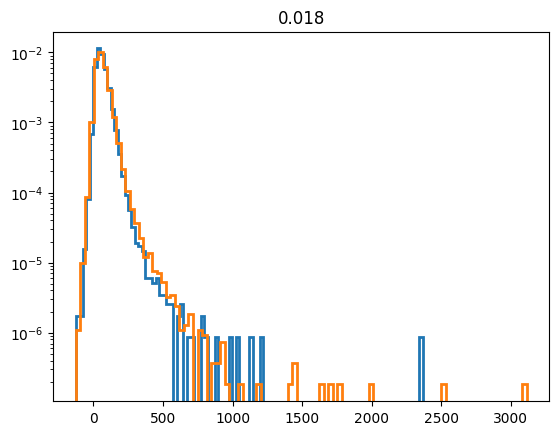

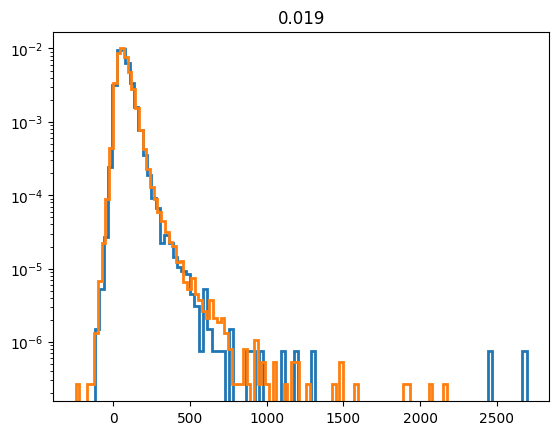

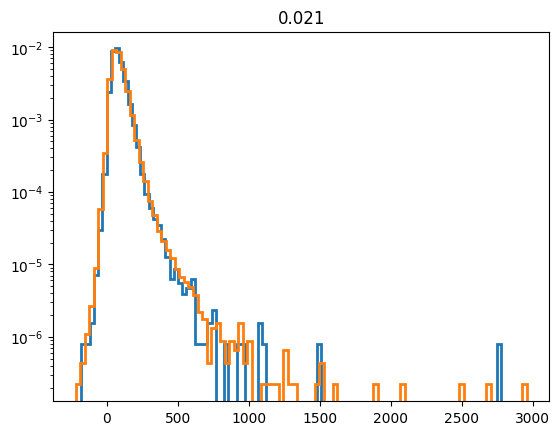

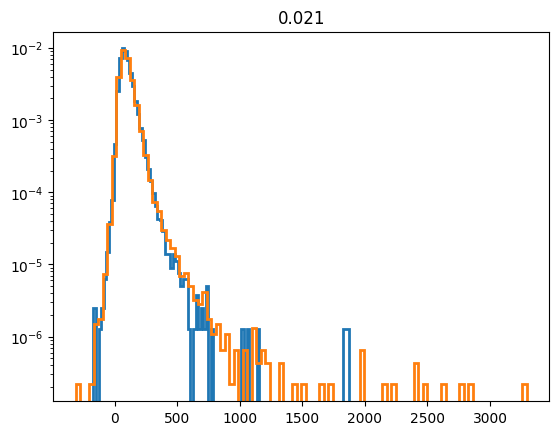

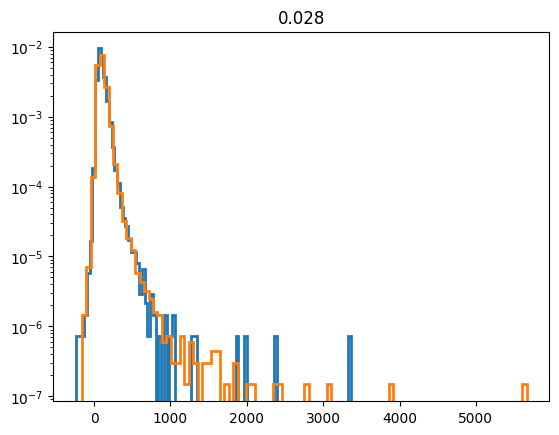

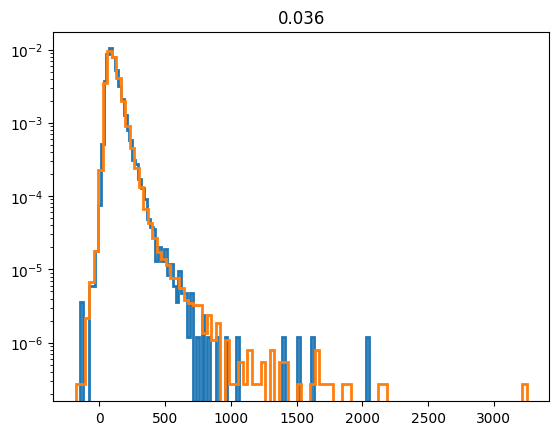

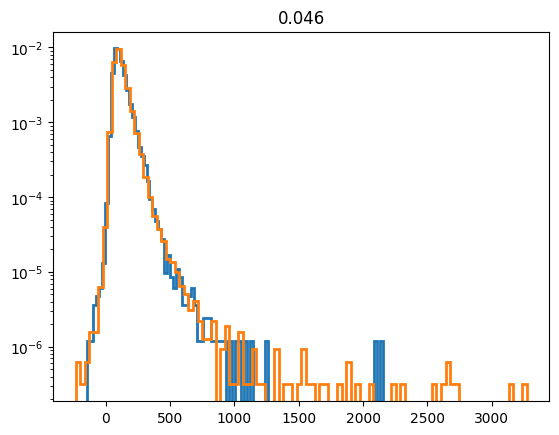

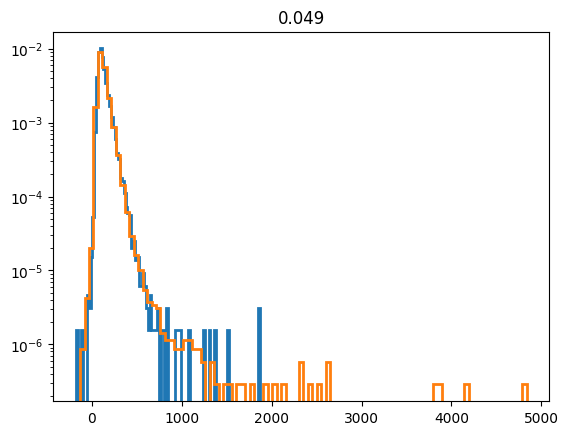

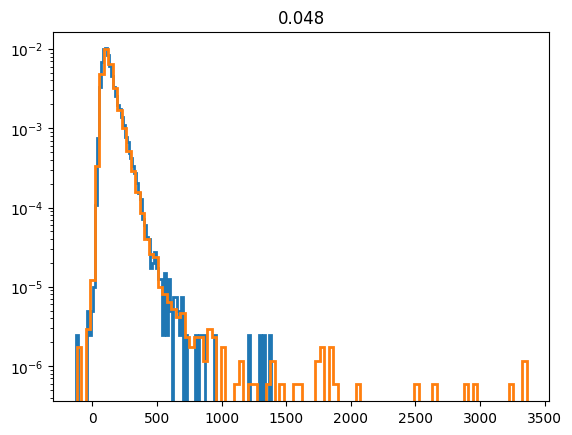

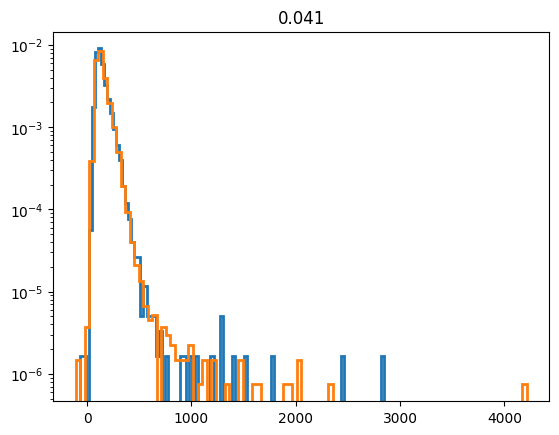

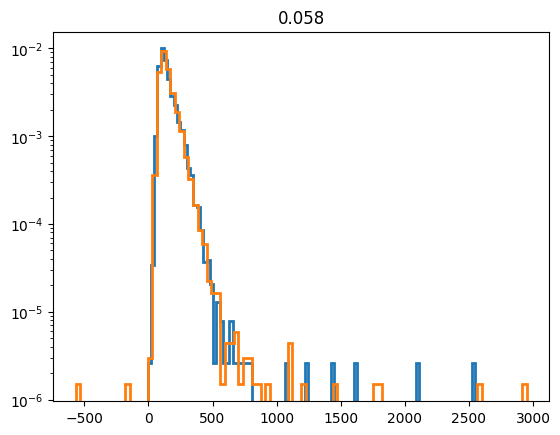

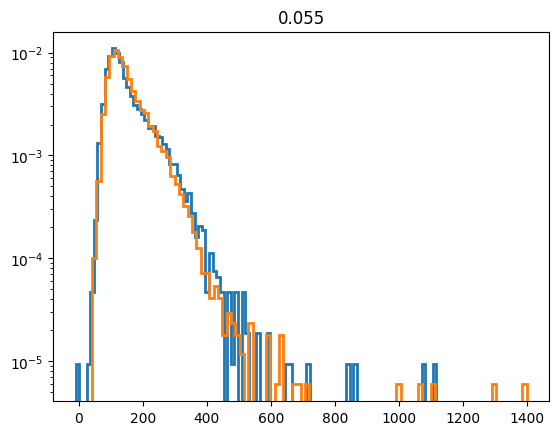

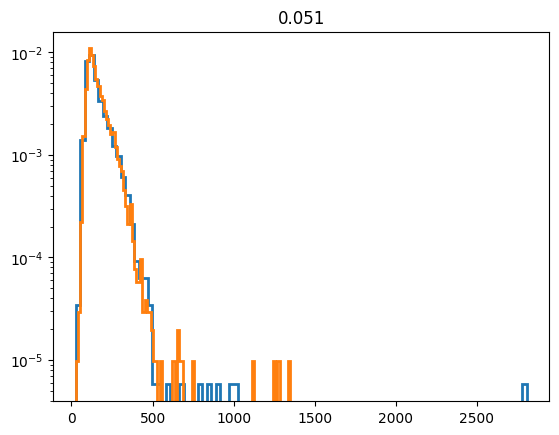

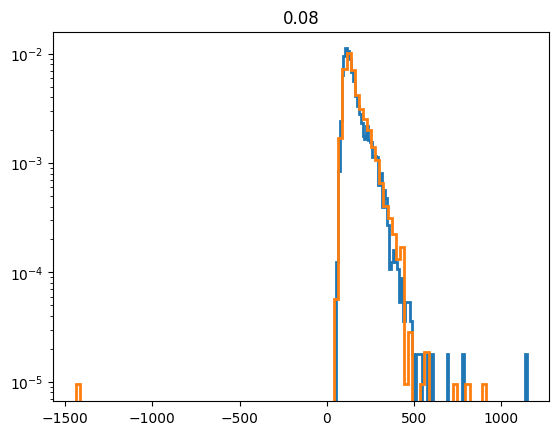

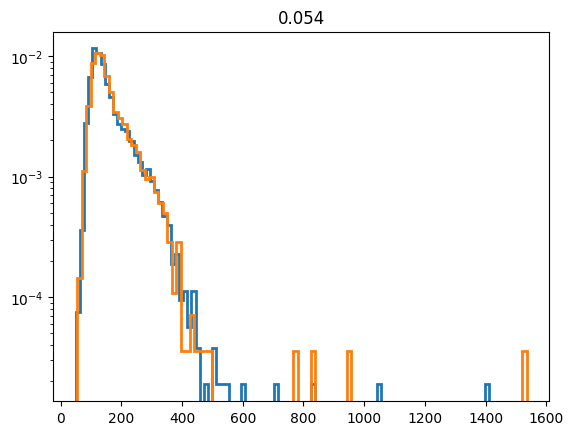

In [11]:
sep_var_mean, p_val_mean, bin_centers_mean = get_statistic(df.tres_mean[boolCC], df.tres_mean[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

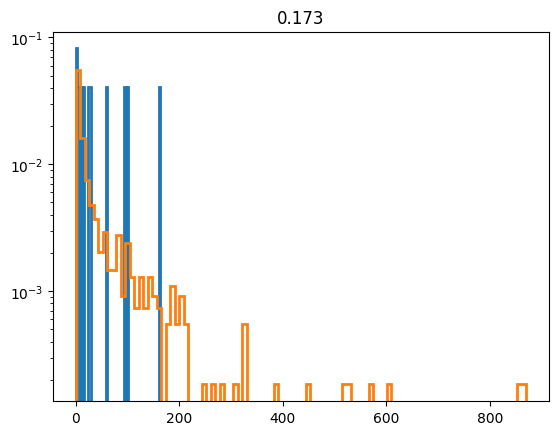

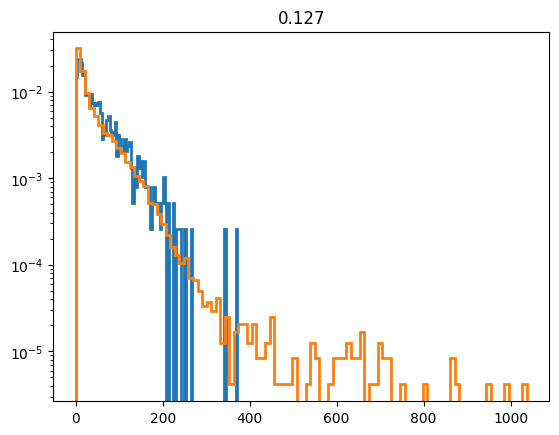

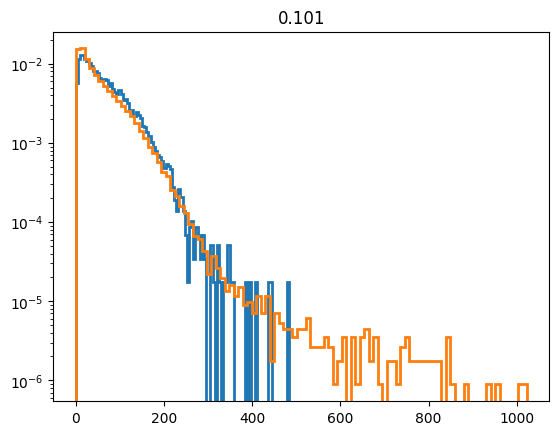

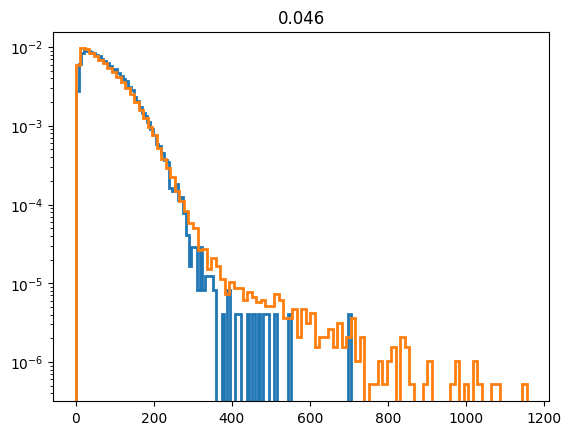

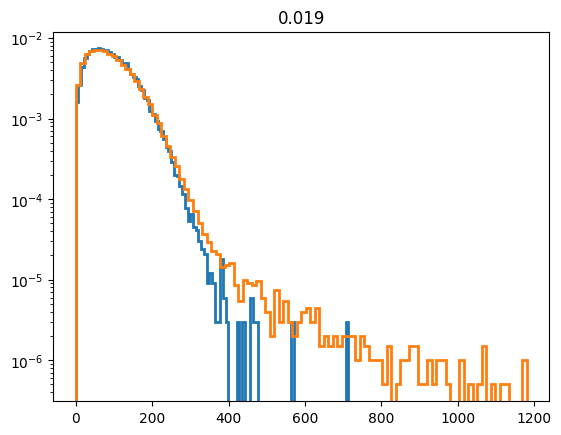

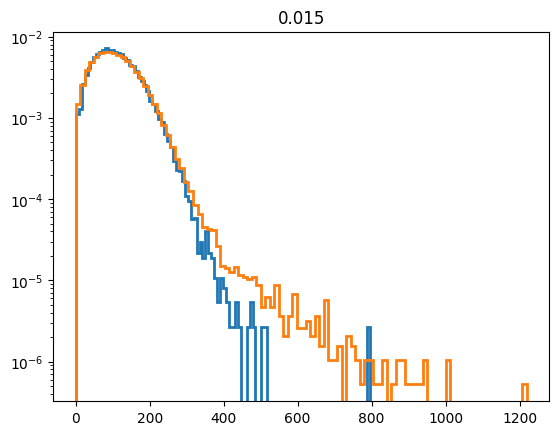

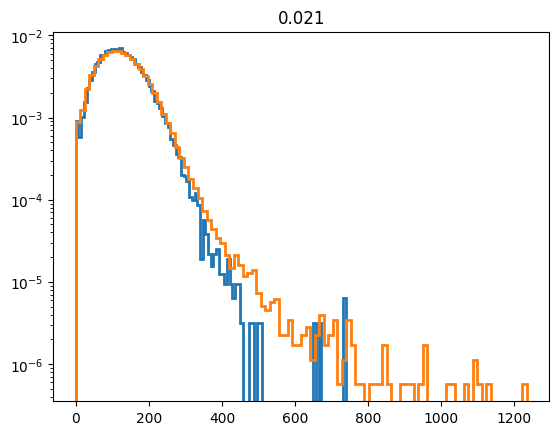

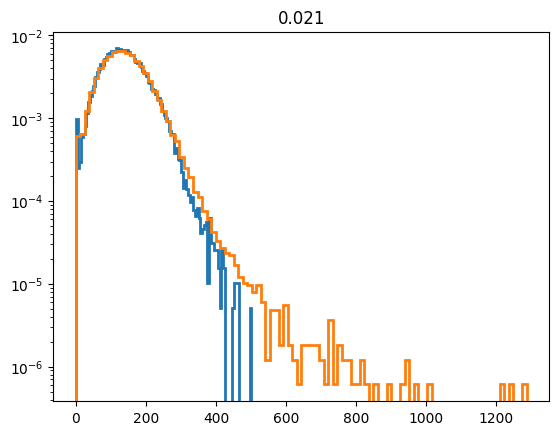

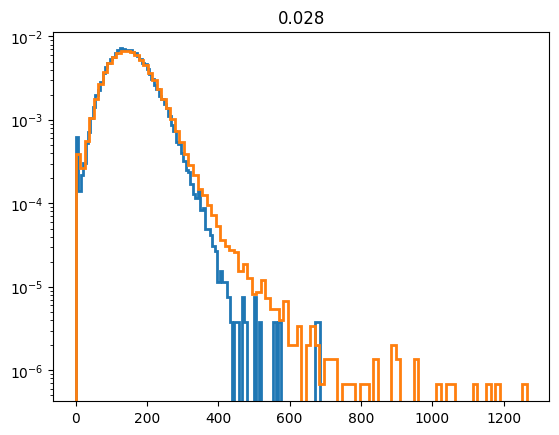

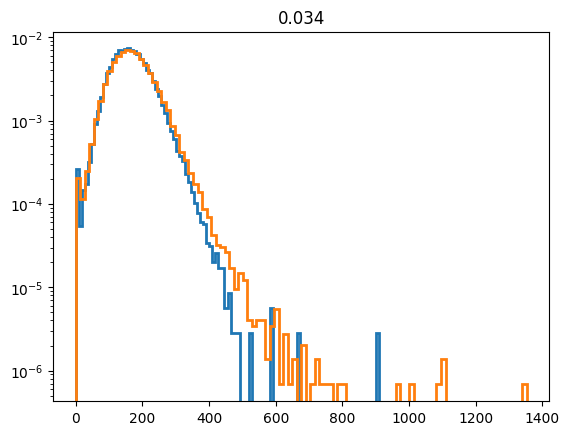

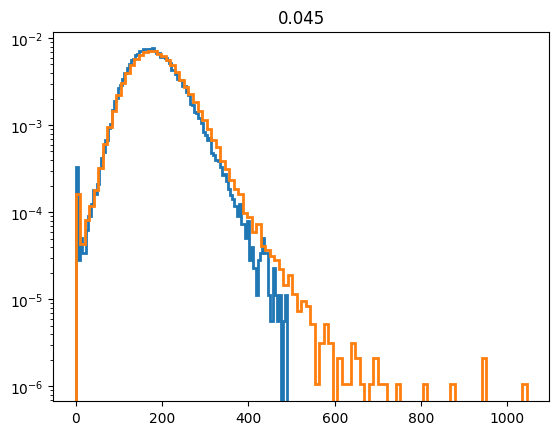

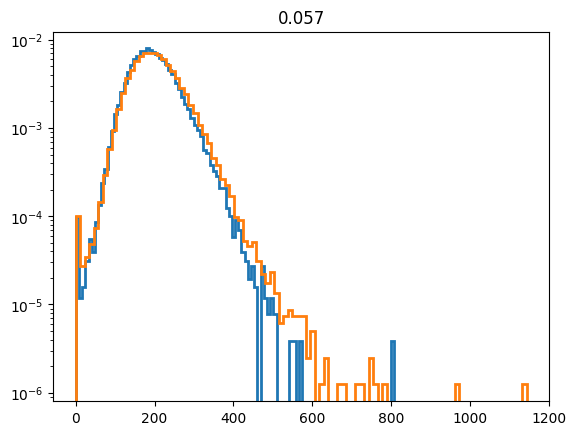

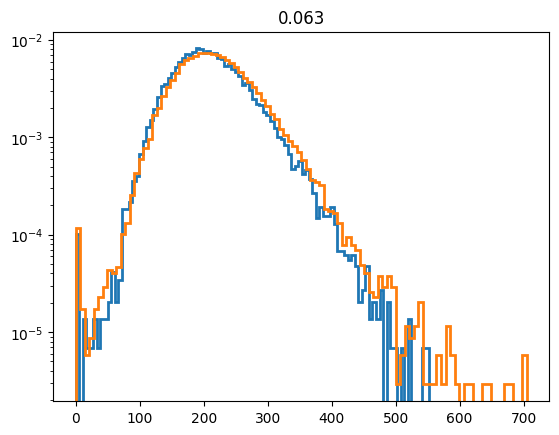

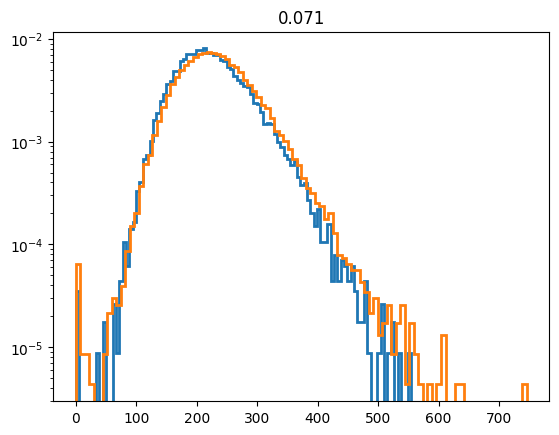

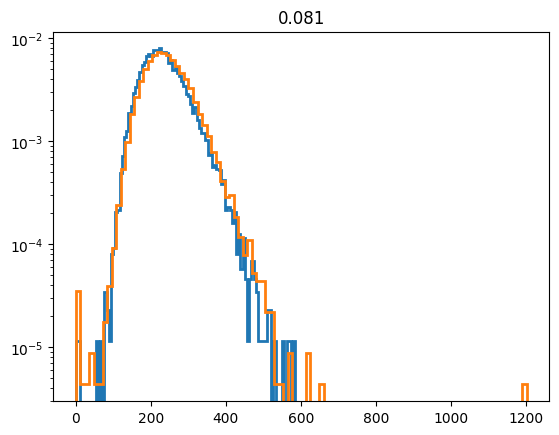

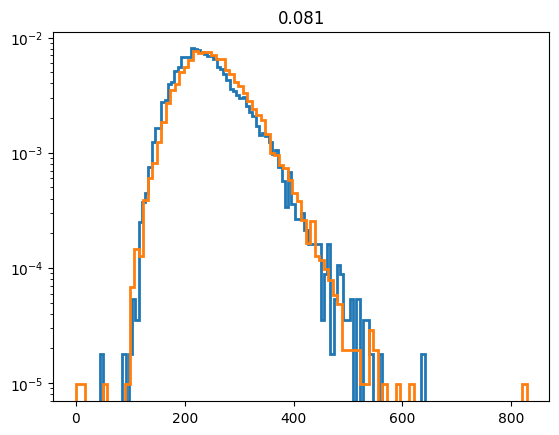

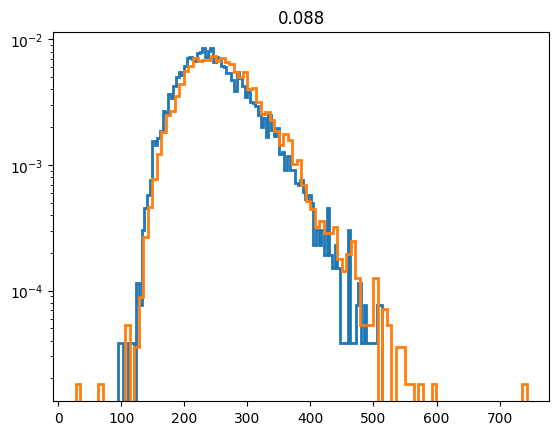

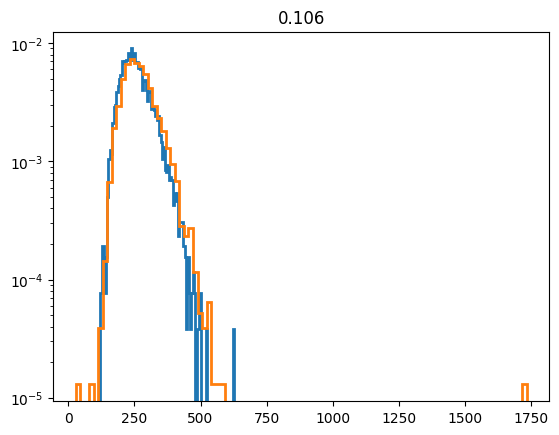

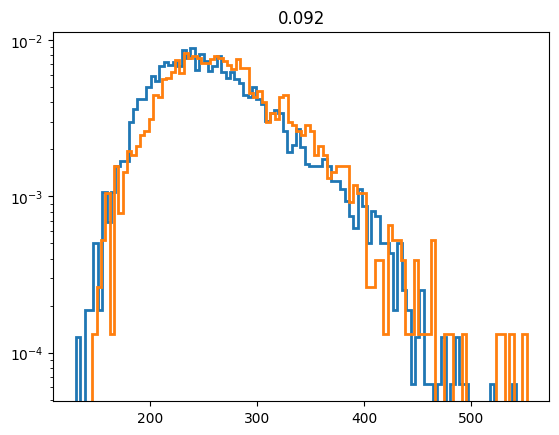

In [12]:
sep_var_std, p_val_std, bin_centers_std = get_statistic(df.tres_std[boolCC], df.tres_std[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

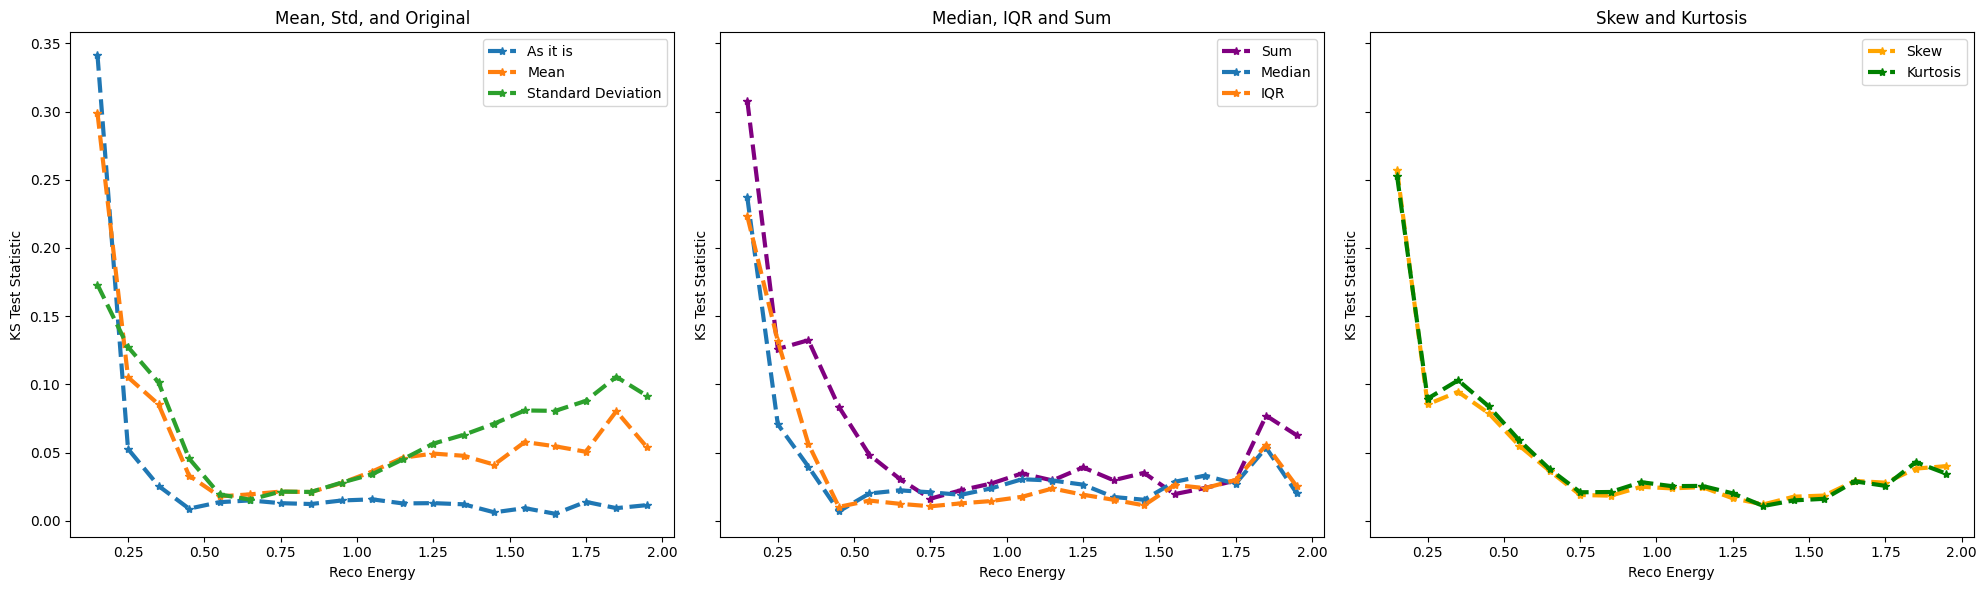

In [15]:
sep_var_mean, p_val_mean, bin_centers_mean = get_statistic(df.tres_mean[boolCC], df.tres_mean[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_std, p_val_std, bin_centers_std = get_statistic(df.tres_std[boolCC], df.tres_std[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_median, p_val_median, bin_centers_median = get_statistic(df.tres_median[boolCC], df.tres_median[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_iqr, p_val_iqr, bin_centers_iqr = get_statistic(df.tres_iqr[boolCC], df.tres_iqr[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_sum, p_val_sum, bin_centers_sum = get_statistic(df.tres_sum[boolCC], df.tres_sum[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_kurtosis, p_val_kurtosis, bin_centers_kurtosis = get_statistic(df.tres_kurtosis[boolCC], df.tres_kurtosis[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_skew, p_val_skew, bin_centers_skew = get_statistic(df.tres_skew[boolCC], df.tres_skew[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(fCC.root.OMMapReco.col('time_residual'), fNC.root.OMMapReco.col('time_residual'), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- Subplot 1 ---
axs[0].plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='As it is')
axs[0].plot(bin_centers_mean, sep_var_mean, '*--', linewidth=3, label='Mean')
axs[0].plot(bin_centers_std, sep_var_std, '*--', linewidth=3, label='Standard Deviation')
axs[0].set_ylabel('KS Test Statistic')
axs[0].set_xlabel('Reco Energy')
axs[0].legend()
axs[0].set_title("Mean, Std, and Original")

# --- Subplot 2 ---
axs[1].plot(bin_centers_sum, sep_var_sum, '*--', linewidth=3, label='Sum', color='purple')
axs[1].plot(bin_centers_median, sep_var_median, '*--', linewidth=3, label='Median')
axs[1].plot(bin_centers_iqr, sep_var_iqr, '*--', linewidth=3, label='IQR')
axs[1].set_ylabel('KS Test Statistic')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].set_title("Median, IQR and Sum")

# --- Subplot 3 ---
axs[2].plot(bin_centers_skew, sep_var_skew, '*--', linewidth=3, label='Skew', color='orange')
axs[2].plot(bin_centers_kurtosis, sep_var_kurtosis, '*--', linewidth=3, label='Kurtosis', color='green')
axs[2].set_xlabel('Reco Energy')
axs[2].set_ylabel('KS Test Statistic')
axs[2].legend()
axs[2].set_title("Skew and Kurtosis")

plt.tight_layout()
plt.show()

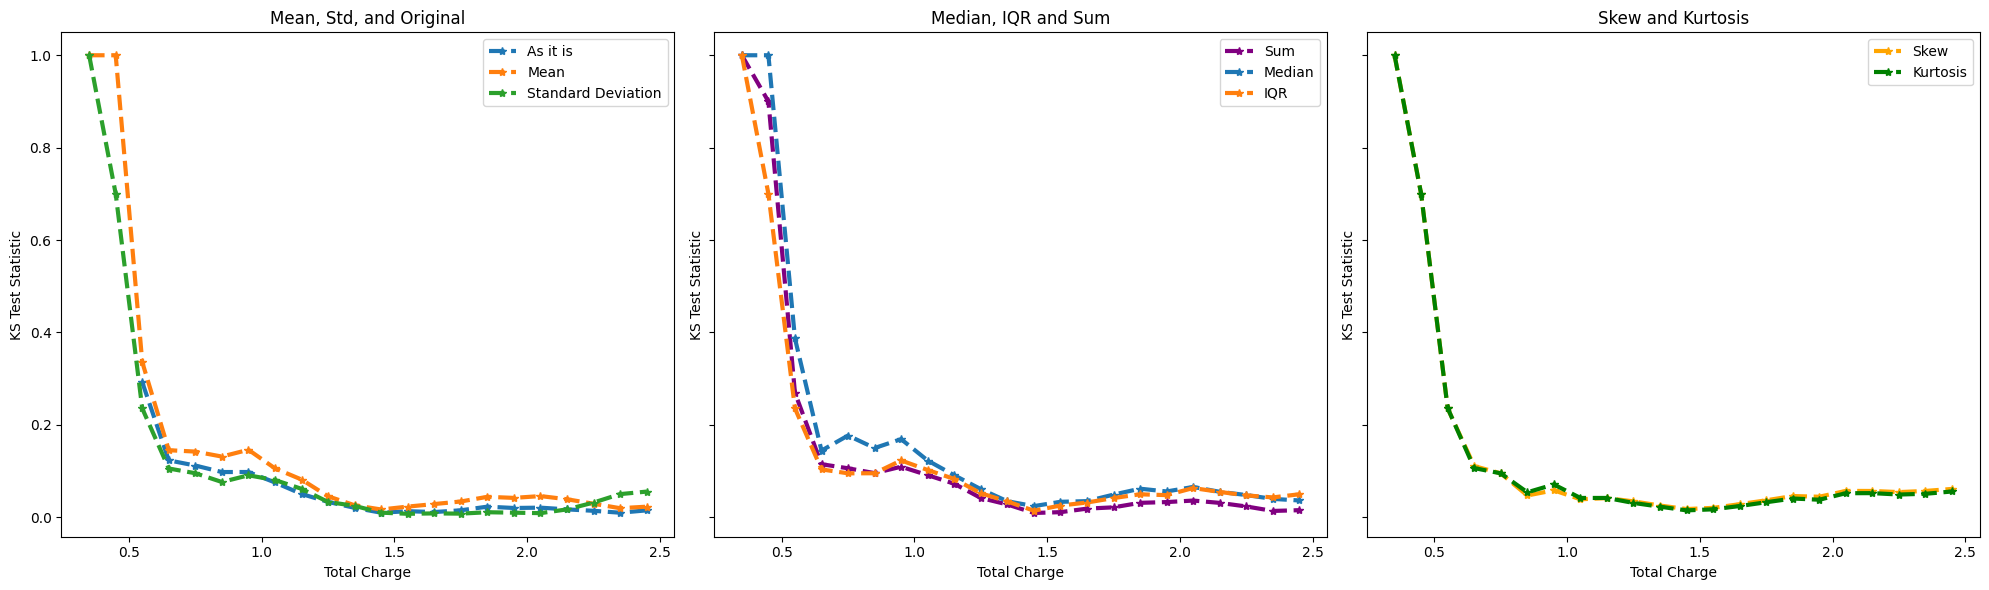

In [16]:
csep_var_mean, cp_val_mean, cbin_centers_mean = get_statistic(df.tres_mean[boolCC], df.tres_mean[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_std, cp_val_std, cbin_centers_std = get_statistic(df.tres_std[boolCC], df.tres_std[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_median, cp_val_median, cbin_centers_median = get_statistic(df.tres_median[boolCC], df.tres_median[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_iqr, cp_val_iqr, cbin_centers_iqr = get_statistic(df.tres_iqr[boolCC], df.tres_iqr[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_sum, cp_val_sum, cbin_centers_sum = get_statistic(df.tres_sum[boolCC], df.tres_sum[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_kurtosis, cp_val_kurtosis, cbin_centers_kurtosis = get_statistic(df.tres_kurtosis[boolCC], df.tres_kurtosis[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_skew, cp_val_skew, cbin_centers_skew = get_statistic(df.tres_skew[boolCC], df.tres_skew[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)

csep_var_angle_reco, cp_val_angle_reco, cbin_centers_angle_reco = get_statistic(fCC.root.OMMapReco.col('time_residual'), fNC.root.OMMapReco.col('time_residual'), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# --- Subplot 1 ---
axs[0].plot(cbin_centers_angle_reco, csep_var_angle_reco, '*--', linewidth=3, label='As it is')
axs[0].plot(cbin_centers_mean, csep_var_mean, '*--', linewidth=3, label='Mean')
axs[0].plot(cbin_centers_std, csep_var_std, '*--', linewidth=3, label='Standard Deviation')
axs[0].set_ylabel('KS Test Statistic')
axs[0].set_xlabel('Total Charge')
axs[0].legend()
axs[0].set_title("Mean, Std, and Original")

# --- Subplot 2 ---
axs[1].plot(cbin_centers_sum, csep_var_sum, '*--', linewidth=3, label='Sum', color='purple')
axs[1].plot(cbin_centers_median, csep_var_median, '*--', linewidth=3, label='Median')
axs[1].plot(cbin_centers_iqr, csep_var_iqr, '*--', linewidth=3, label='IQR')
axs[1].set_ylabel('KS Test Statistic')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].set_title("Median, IQR and Sum")

# --- Subplot 3 ---
axs[2].plot(cbin_centers_skew, csep_var_skew, '*--', linewidth=3, label='Skew', color='orange')
axs[2].plot(cbin_centers_kurtosis, csep_var_kurtosis, '*--', linewidth=3, label='Kurtosis', color='green')
axs[2].set_xlabel('Total Charge')
axs[2].set_ylabel('KS Test Statistic')
axs[2].legend()
axs[2].set_title("Skew and Kurtosis")

plt.tight_layout()
plt.show()